# DataProject: Population Projection in Denmark

**TABLE OF CONTENTS**
1. Project description
2. Installations and imports
3. Importing, processing and cleaning data
4. Analysis \
    4.1. Summary Statistics \
    4.2. Figures and analysis  
5. Conclusion


## 1. Project description

This project focuses on analyzing population projection data for municipalities in Denmark from 2023 to 2050. The dataset is sourced from Statistics Denmark using the DstApi, enabling us to fetch and process demographic data. The goal is to import, clean, analyze, and visualize this data to gain insights into population trends over the specified period.\
\
Key steps include renaming columns, filtering data by municipality and age group, and aggregating population projections. The analysis highlights changes in population distribution across age groups over time, facilitating a comprehensive understanding of demographic shifts.\
\
An interactive figure compares population projections for 2023 and 2050 across age groups within each municipality. These insights are crucial for informing urban planning strategies and public policy decisions based on anticipated demographic changes.



## 2. Installations and imports


First, we install an API, so we can import data from Statistics Denmark (DST). We also import relevant packages for our analysis.

In [1]:
#Installing the DST API wrapper
%pip install git+https://github.com/alemartinello/dstapi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/bp/5bcyz08918xf83w51sf_k8p00000gn/T/pip-req-build-pd7o76v8
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/bp/5bcyz08918xf83w51sf_k8p00000gn/T/pip-req-build-pd7o76v8
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importing relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import re
%load_ext autoreload
%autoreload 2
from dstapi import DstApi


In [3]:
from dataproject import Classdataproject

# Create an instance of the Classdataproject
project = Classdataproject()

# 3. Importing, processing and cleaning data
We do all of our importing, processing and cleaning in one step in this notebook. The steps are divided into several steps in the .py file.
In short, we:
- Import data from Statistics Denmark
- Rename the variables to attain English variable names
- Sum up the gender values (we are only interested in analysing the sexes in total)
- Create age groups of ten years
- Sort the dataframe
- Add 'Denmark' as a total to the municipality column (for every combination of year and age group)
- Sum up the age groups to attain 'sum of ages'
- Create a variable that gives the age groups' share of total population

*Further details in the dataproject.py file.*

In [4]:
# Import data
FRKM123, params = project.import_data('FRKM123')

# Rename columns
df = project.rename(FRKM123, params)
if df is not None:
    # Process data
    df = project.process_data(df)
    if df is not None:
        # Sorting data
        df = project.sort_data(df)
        if df is not None:
            # Summarize projection
            df = project.summarize_projection(df)
            if df is not None:
                # Calculate total population
                df, total_population = project.calculate_total_population(df)
                if df is not None and total_population is not None:
                    # Calculate population share
                    df = project.calculate_population_share(df, total_population)
                    if df is not None:
                        # Display the resulting dataframe for verification
                        print(df)
                    else:
                        print("Population share calculation failed.")
                else:
                    print("Total population calculation failed.")
            else:
                print("Summarization failed.")
        else:
            print("Data sorting failed.")
    else:
        print("Data processing failed.")
else:
    print("Dataframe is None")


Table FRKM123: Population projections 2023 by region, age, sex and time
Last update: 2023-06-01T08:00:00


/Users/andreaandersen/projects-2024-agnete-og-andrea-15/dataproject/dataproject.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['pop_proj_age'] = df.groupby(['municipality', 'age_group', 'year'])['pop_proj_all'].transform(sumval)


      municipality  year    age_group  population_projection  pop_share
0         Aabenraa  2023          0-9                   5820   0.098641
1         Aabenraa  2023        10-19                   7129   0.120826
2         Aabenraa  2023        20-29                   5297   0.089777
3         Aabenraa  2023        30-39                   6192   0.104946
4         Aabenraa  2023        40-49                   7020   0.118979
...            ...   ...          ...                    ...        ...
33224          Ærø  2050        70-79                    939   0.160568
33225          Ærø  2050        80-89                    780   0.133379
33226          Ærø  2050        90-99                    211   0.036081
33227          Ærø  2050         100+                      8   0.001368
33228          Ærø  2050  sum of ages                   5848   1.000000

[33229 rows x 5 columns]


/Users/andreaandersen/projects-2024-agnete-og-andrea-15/dataproject/dataproject.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summarized_data = df.groupby(['year', 'age_group'])['population_projection'].sum().reset_index()


**This is our final dataset that we will use in our further analysis.**

## 4. Analysis

### 4.1. Summary statistics

We will now make a descriptive table of our data:

In [5]:
project.generate_descriptive_table(df)

Table 1: Descriptive Statistics


,Attribute,Value
0,Number of Municipalities,98
1,Number of Years,28
2,First Year,"2,023"
3,Last Year,"2,050"
4,Number of Age Groups,11
5,Min Population (2023),"1,789"
6,Max Population (2023),"653,664"
7,Mean Population (2023),"60,533"
8,Median Population (2023),"43,795"


***Comments on the table:***

Table 1 shows some summary statistics of our dataset. There are 98 municipalities in the dataset. Besides, we have data for Denmark in total. It consists of 28 years (from 2023 to 2050). There are 11 age groups divided into intervals of 10 years, i.e. 0-9, 10-19, ..., 100+.

In 2023, the municipality with the smallest population had 1,789 citizens, while the municipality with the largest population had 653,664 citizens. The average population size in 2023 was 60,553 citizens.

---

To investigate the data further, we will find the municipalities with the smallest and largest populations in 2023:

In [6]:
project.small_large_municipality(df)

Municipality with the smallest population in 2023:
municipality                    Læsø
year                            2023
age_group                sum of ages
population_projection           1789
pop_share                        1.0
Name: 19485, dtype: object
Municipality with the largest population in 2023:
municipality              Copenhagen
year                            2023
age_group                sum of ages
population_projection         653664
pop_share                        1.0
Name: 3701, dtype: object


We see that Læsø is the municipality with the smallest population in 2023 (1,789 persons) and Copenhagen is the municipality with the largest population in 2023 (653,664 persons).

### 4.2. Figures and analysis

#### ***Figure 1: Population Projection for Denmark 2023 - 2050***

The want to look at the population projection for Denmark over the total span of years. For this, we plot a figure as below.

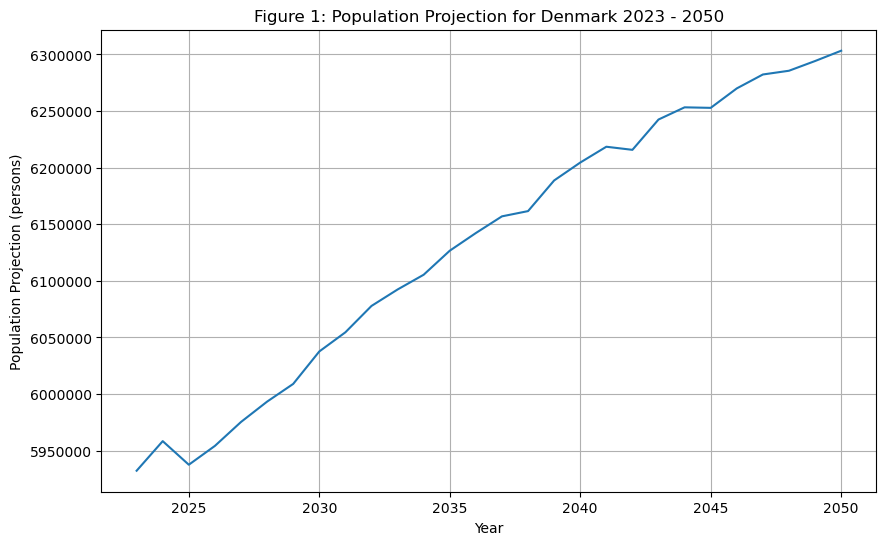

In [7]:
project.plot_population_projection(df)

***Comments on the figure:***\
\
Overall, the population is projected to rise from about 5.9 million people in 2023 to just over 6.3 million people in 2050. This is an increase of over 350,000 people - an average increase of 12,500 persons per year. As can be seen on the figure, the increase in population is projected to be relatively stable over the years, with only minor fluctuations. A significant outlier is a decrease in 2025. This can be attributed to an assumption of a high rate of emigration of Ukrainian refugees.

#### ***Figure 2: Population Share by Age Group in 2023 and 2050***

We want to investigate the demographic transition in Denmark and in each municipality. We make an interactive figure that shows the population share of each age group in 2023 and in 2050 for all municipalities in Denmark.

In [8]:
project.add_population_shares(df)

widgets.interact(project.plot_interactive, 
    df = widgets.fixed(df),
    municipality = widgets.Dropdown(description='Municipality', 
                                    options=df.municipality.unique(), 
                                    value='Roskilde')
);

interactive(children=(Dropdown(description='Municipality', index=73, options=('Aabenraa', 'Aalborg', 'Aarhus',…

***Comments on the figure:***

The interactive figure shows the population shares by age group for each municipality and for Denmark in total in the years 2023 and 2050. Thereby, we can use the figure to look at the demographic transition in Denmark from now until 2050.

In general, the figure shows the coming demographic burden; The population share of the old age groups is increasing, while the population share of the young people in the labor age is decreasing.

When looking at Denmark in total, we see that the age groups from 0 to 79 years have some what equally population shares in 2023 (10-14%). In 2050, we see that the population of Denmark will consist of a larger share of people in the age groups from 70 years to 99 years and a smaller share of young people.

The distribution of age groups in Copenhagen is quite different from Denmark in total. Copenhagen is a city with a large share of people in the age group 20-39 years. But we see the same generel trend in Copenhagen as in Denmark in total, since the population share of the old age groups are increasing while the population share of the people aged 20-59 decreases.

## 5. Conclusion

In conclusion, the figures have shown that the population of Denmark is growing. Figure 1 shows that in 2050, the population will be approx. 6.3 millions, i.e. an increase of 350,000 citizens since 2023.

Figure 2 is an interactive figure that illustrates the demographic burden; The population shares of the old age groups will be larger in 2050, while the population shares of the younger age groups will be smaller.

Our analysis shows that the population in total will increase, and that for many municipalities, the older age groups are increasing more, resulting in higher expected expenditures on e.g. healthcare and public nursing facilities.